# Сравнение с литературными моделями

**Цель:** обучить две внешние модели с открытым кодом на **наших данных** (тот же сплит `random_state=42`) и сравнить с нашими лучшими дескрипторными и GNN моделями.

| Модель | Тип | Статья |
|--------|-----|--------|
| **Chemprop D-MPNN** | GNN (D-MPNN) | Heid et al., J. Chem. Inf. Model., 2024 |
| **fastprop** | Дескрипторная DNN (Mordred) | Burns & Spronk, J. Cheminform., 2025 |

Оба пакета устанавливаются через pip и принимают SMILES как вход.

**Сплит:** `test_size=0.20, random_state=42` — идентичен `modeling.ipynb` и `gnn.ipynb`  
**Данные:** `data_ml/merged_nbp_clean.sdf`, 8572 молекул

## 0. Установка зависимостей

Запустить один раз. Chemprop и fastprop устанавливаются через pip.

In [ ]:
# Запустить один раз для установки
import subprocess, sys

def pip_install(pkg):
    result = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                            capture_output=True, text=True)
    if result.returncode == 0:
        print(f'✅ {pkg} установлен')
    else:
        print(f'❌ {pkg} ошибка: {result.stderr[-300:]}')

pip_install('chemprop>=2.0')
pip_install('fastprop')

## 1. Импорты и пути

In [9]:
import numpy as np
import pandas as pd
import subprocess, sys, os
from pathlib import Path
from rdkit import Chem
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── пути
ROOT       = Path(r'C:\Users\User\Desktop\диплом тест')
SDF_PATH   = ROOT / 'data_ml' / 'merged_nbp_clean.sdf'
OUT_DIR    = ROOT / 'modeling' / 'comparison_data'
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20

print('ROOT:', ROOT)
print('SDF:', SDF_PATH.exists())

ROOT: C:\Users\User\Desktop\диплом тест
SDF: True


## 2. Подготовка данных

Извлекаем SMILES и Tb из SDF, делаем **тот же сплит**, что в `modeling.ipynb`.

In [10]:
# Читаем SDF через ForwardSDMolSupplier (поддерживает Unicode-пути).
# Берём только нужные свойства напрямую — GetPropsAsDict() падает на
# кириллице в поле 'compound' (CP1251 vs UTF-8).
smiles_list, bp_list = [], []

with open(SDF_PATH, 'rb') as f:
    suppl = Chem.ForwardSDMolSupplier(f, removeHs=False)
    for mol in suppl:
        if mol is None:
            continue
        try:
            smi = mol.GetProp('SMILES')
        except KeyError:
            smi = Chem.MolToSmiles(mol)
        try:
            bp = float(mol.GetProp('Temperature_Celsius'))
        except (KeyError, ValueError):
            continue
        if smi:
            smiles_list.append(smi)
            bp_list.append(bp)

df = pd.DataFrame({'smiles': smiles_list, 'bp': bp_list})
print(f'Всего молекул: {len(df)}')
print(f'BP: min={df.bp.min():.1f}°C  max={df.bp.max():.1f}°C  mean={df.bp.mean():.1f}°C')
df.head(3)

Всего молекул: 8572
BP: min=-161.5°C  max=590.5°C  mean=179.4°C


,smiles,bp
0,C[CH2][Al]([Cl])[CH2]C,208.0
1,C[CH2][Hg][CH2]C,159.0
2,C[CH2][Zn][CH2]C,118.0


In [11]:
# Сплит — идентичен modeling.ipynb
idx_all = np.arange(len(df))
train_idx, test_idx = train_test_split(idx_all, test_size=TEST_SIZE, random_state=RANDOM_STATE)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

print(f'Train: {len(df_train)}  |  Test: {len(df_test)}')

# Сохраняем CSV
train_csv = OUT_DIR / 'train.csv'
test_csv  = OUT_DIR / 'test.csv'
df_train.to_csv(train_csv, index=False)
df_test.to_csv(test_csv,   index=False)
print('CSV сохранены:', OUT_DIR)

Train: 6857  |  Test: 1715
CSV сохранены: C:\Users\User\Desktop\диплом тест\modeling\comparison_data


## 3. Chemprop (D-MPNN)

**Архитектура:** D-MPNN — directed message passing neural network.  
Heid E. et al., *J. Chem. Inf. Model.*, 2024, DOI: 10.1021/acs.jcim.3c01250  
GitHub: https://github.com/chemprop/chemprop

---

### ⚙️ О выборе гиперпараметров для литературных моделей

Chemprop (Yang 2019 / Heid 2024):
В оригинальных статьях запускают chemprop hpopt — встроенный байесовский поиск гиперпараметров (глубина, hidden_dim, dropout, FFN-слои). У Heid 2024 это явно описано как стандартная процедура.

fastprop (Burns 2025):
В статье тоже подбирают hidden_size, fnn_layers, learning_rate — именно оптимизированные модели идут в итоговое сравнение.

Оба пакета запущены с **дефолтными гиперпараметрами** (Chemprop: `depth=3, hidden_size=300, dropout=0.0`; fastprop: дефолтная конфигурация FNN). Это осознанный методологический выбор: данный раздел ставит вопрос *«насколько хорошо работают опубликованные инструменты при применении к новому датасету без дополнительной настройки?»* — именно так их использует большинство исследователей в реальных проектах.

Полученные метрики при этом являются **заниженной оценкой** возможностей этих архитектур: с тюнингом (например, `chemprop hpopt`) их результаты были бы выше. Поэтому особенно показательно, что даже в базовой конфигурации Chemprop и fastprop вышли на уровень наших оптимизированных GNN (AttentiveFP R²=0.682 vs Chemprop R²=0.670). Это говорит о высоком качестве этих архитектур, а не об ограничениях подхода.

In [16]:
import shutil

CHEMPROP_WORKDIR = Path(r'C:\tmp\chemprop_bp')
CHEMPROP_WORKDIR.mkdir(parents=True, exist_ok=True)
chemprop_preds_csv = CHEMPROP_WORKDIR / 'preds.csv'

# ── Проверяем импорт chemprop
try:
    import chemprop
    print(f'✅ chemprop {chemprop.__version__} импортирован')
except Exception as e:
    print(f'❌ Импорт chemprop упал: {e}')
    raise

✅ chemprop 2.2.3 импортирован


In [17]:
import torch
import lightning as pl
from chemprop.data import MoleculeDatapoint, MoleculeDataset, build_dataloader
from chemprop.featurizers import SimpleMoleculeMolGraphFeaturizer
from chemprop.models import MPNN
from chemprop.nn import BondMessagePassing, MeanAggregation, RegressionFFN
from chemprop.nn.metrics import RMSE

# ── Подготовка данных
smis_train = df_train['smiles'].tolist()
ys_train   = df_train['bp'].values.reshape(-1, 1).tolist()   # [[y1], [y2], ...]

smis_test  = df_test['smiles'].tolist()

featurizer = SimpleMoleculeMolGraphFeaturizer()

train_data = [MoleculeDatapoint.from_smi(smi, y)
              for smi, y in zip(smis_train, ys_train)]
test_data  = [MoleculeDatapoint.from_smi(smi) for smi in smis_test]

train_dset = MoleculeDataset(train_data, featurizer=featurizer)
test_dset  = MoleculeDataset(test_data,  featurizer=featurizer)

# Нормализация таргетов (scaler сохраняем для денормализации)
scaler = train_dset.normalize_targets()
print(f'Scaler: mean={scaler.mean_[0]:.1f}  std={scaler.scale_[0]:.1f}')

# Train / Val сплит (10% val из train)
val_size   = int(0.1 * len(train_dset))
train_size = len(train_dset) - val_size
train_sub, val_sub = torch.utils.data.random_split(
    train_dset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = build_dataloader(train_sub, num_workers=0, shuffle=True)
val_loader   = build_dataloader(val_sub,   num_workers=0, shuffle=False)
test_loader  = build_dataloader(test_dset, num_workers=0, shuffle=False)

print(f'Train: {train_size}  Val: {val_size}  Test: {len(test_dset)}')

Scaler: mean=179.3  std=81.6
Train: 6172  Val: 685  Test: 1715


In [20]:
import time

# ── Сначала замеряем скорость 1 эпохи
mp  = BondMessagePassing()
agg = MeanAggregation()
ffn = RegressionFFN()
mpnn = MPNN(mp, agg, ffn)

trainer_test = pl.Trainer(
    max_epochs=1,
    accelerator='auto',
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=False,
)

t0 = time.time()
trainer_test.fit(mpnn, train_loader, val_loader)
t1 = time.time()

epoch_sec = t1 - t0
total_50  = epoch_sec * 50
print(f'⏱ 1 эпоха: {epoch_sec:.1f} сек')
print(f'📊 Прогноз для 50 эпох: {total_50/60:.1f} мин')
print()

# ── Выбираем число эпох по реальному времени
n_epochs = 50 if total_50 < 3600 else 20
print(f'Запускаем {n_epochs} эпох...')

mp2  = BondMessagePassing()
agg2 = MeanAggregation()
ffn2 = RegressionFFN()
mpnn = MPNN(mp2, agg2, ffn2)

trainer = pl.Trainer(
    max_epochs=n_epochs,
    accelerator='auto',
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=False,
)

t_start = time.time()
trainer.fit(mpnn, train_loader, val_loader)
print(f'✅ Обучение завершено за {(time.time()-t_start)/60:.1f} мин')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1.273                                                                      
Modules in train mode: 24                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Loading `train_dataloader` to estimate number of stepping batches.


⏱ 1 эпоха: 6.1 сек
📊 Прогноз для 50 эпох: 5.1 мин

Запускаем 50 эпох...


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1.273                                                                      
Modules in train mode: 24                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=50` reached.


✅ Обучение завершено за 5.3 мин


In [21]:
# ── Предсказание и метрики Chemprop
with torch.no_grad():
    preds_raw = trainer.predict(mpnn, test_loader)

y_pred_norm     = np.concatenate([p.numpy().flatten() for p in preds_raw])
y_pred_chemprop = y_pred_norm * scaler.scale_[0] + scaler.mean_[0]
y_true          = df_test['bp'].values

r2   = r2_score(y_true, y_pred_chemprop)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_chemprop))
mae  = mean_absolute_error(y_true, y_pred_chemprop)

chemprop_metrics = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
print(f'🔵 Chemprop D-MPNN:  R²={r2:.3f}  RMSE={rmse:.1f}°C  MAE={mae:.1f}°C')

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


🔵 Chemprop D-MPNN:  R²=0.670  RMSE=47.0°C  MAE=31.0°C


## 4. fastprop (Mordred + FNN)

**Архитектура:** автоматическая генерация ~1800 дескрипторов Mordred + полносвязная нейронная сеть.  
Burns J.A., Spronk S.A., *J. Cheminform.*, 2025, DOI: 10.1186/s13321-025-01013-4  
GitHub: https://github.com/JacksonBurns/fastprop

> ⏱ Расчёт Mordred-дескрипторов для 8572 молекул занимает ~5-15 мин (кэшируется).

In [25]:
import shutil, time

FASTPROP_WORKDIR = Path(r'C:\tmp\fastprop_bp')
FASTPROP_WORKDIR.mkdir(parents=True, exist_ok=True)
train_csv_fp   = FASTPROP_WORKDIR / 'train.csv'
shutil.copy(train_csv, train_csv_fp)
fastprop_model_dir = FASTPROP_WORKDIR / 'model'
fastprop_preds_csv = FASTPROP_WORKDIR / 'preds.csv'

fastprop_exe = shutil.which('fastprop')
if fastprop_exe is None:
    scripts_dir = Path(sys.executable).parent / 'Scripts'
    for c in ['fastprop.exe', 'fastprop']:
        p = scripts_dir / c
        if p.exists():
            fastprop_exe = str(p); break

print(f'✅ fastprop: {fastprop_exe}')

ftrain_cmd = [
    fastprop_exe, 'train',
    '--input-file',       str(train_csv_fp),
    '--smiles-column',    'smiles',
    '--target-columns',   'bp',
    '--output-directory', str(fastprop_model_dir),
    '--number-epochs',    '50',
]

print('Запуск fastprop train...')
t0 = time.time()
result3 = subprocess.run(ftrain_cmd, capture_output=True,
                         text=True, encoding='utf-8', errors='replace')
elapsed = (time.time() - t0) / 60
print(f'Время: {elapsed:.1f} мин  |  returncode: {result3.returncode}')
print('=== STDOUT ===')
print(result3.stdout[-3000:] if result3.stdout else '(пусто)')
if result3.returncode != 0:
    print('=== STDERR ===')
    print(result3.stderr[:2000] if result3.stderr else '(пусто)')

✅ fastprop: C:\Users\User\AppData\Local\Programs\Python\Python312\Scripts\fastprop.EXE
Запуск fastprop train...
Время: 3.8 мин  |  returncode: 0
=== STDOUT ===
/3 0:00:01 • 0:00:00 2.72it/s v_num: on_1
Epoch 16/49 ------------------------ 0/3 0:00:01 • 0:00:00 0.00it/s v_num: on_1
Epoch 16/49 ------------------------ 0/3 0:00:01 • 0:00:00 0.00it/s v_num: on_1
Epoch 16/49 -------- --------------- 1/3 0:00:00 • -:--:-- 0.00it/s v_num: on_1
Epoch 16/49 ---------------- ------- 2/3 0:00:00 • 0:00:01 2.21it/s v_num: on_1
Epoch 16/49 ------------------------ 3/3 0:00:01 • 0:00:00 2.67it/s v_num: on_1
Epoch 16/49 ------------------------ 3/3 0:00:01 • 0:00:00 2.67it/s v_num: on_1
Epoch 16/49 ------------------------ 3/3 0:00:01 • 0:00:00 2.67it/s v_num: on_1
Epoch 17/49 ------------------------ 0/3 0:00:01 • 0:00:00 0.00it/s v_num: on_1
Epoch 17/49 ------------------------ 0/3 0:00:01 • 0:00:00 0.00it/s v_num: on_1
Epoch 17/49 -------- --------------- 1/3 0:00:00 • -:--:-- 0.00it/s v_num: on_

In [29]:
import os

# Пути модели
model_run_dir  = sorted(FASTPROP_WORKDIR.glob('model/fastprop_*'))[-1]
checkpoints_dir = model_run_dir / 'checkpoints'
print(f'checkpoints_dir: {checkpoints_dir}')

# Файл со SMILES без заголовка (fastprop predict требует plain SMILES)
test_smiles_txt = FASTPROP_WORKDIR / 'test_smiles.txt'
df_test['smiles'].to_csv(test_smiles_txt, index=False, header=False)
print(f'SMILES файл: {test_smiles_txt}  ({len(df_test)} строк)')

fpred_cmd = [
    fastprop_exe, 'predict',
    str(checkpoints_dir),              # позиционный аргумент
    '--smiles-file',    str(test_smiles_txt),
    '--descriptor-set', 'all',         # тот же набор что при обучении (дефолт)
    '--output',         str(fastprop_preds_csv),
]

print('Запуск fastprop predict...')
result4 = subprocess.run(fpred_cmd, capture_output=True,
                         text=True, encoding='utf-8', errors='replace')
print(f'returncode: {result4.returncode}')
print(result4.stdout[:1000] if result4.stdout else '(stdout пусто)')
if result4.returncode != 0:
    print('STDERR:', result4.stderr[:1500])

checkpoints_dir: C:\tmp\fastprop_bp\model\fastprop_1780342356\checkpoints
SMILES файл: C:\tmp\fastprop_bp\test_smiles.txt  (1715 строк)
Запуск fastprop predict...
returncode: 0

Predicting ---------------------------------- 0/14 0:00:00 • -:--:-- 0.00it/s 
Predicting ---------------------------------- 0/14 0:00:00 • -:--:-- 0.00it/s 
Predicting -- ------------------------------- 1/14 0:00:00 • -:--:-- 0.00it/s 
Predicting ------ ------------------------- 3/14 0:00:00 • 0:00:01 133.33it/s 
Predicting --------- ----------------------- 4/14 0:00:00 • 0:00:01 96.77it/s 
Predicting ----------- --------------------- 5/14 0:00:00 • 0:00:01 85.11it/s 
Predicting -------------- ------------------ 6/14 0:00:00 • 0:00:01 80.65it/s 
Predicting ---------------- ---------------- 7/14 0:00:00 • 0:00:01 96.77it/s 
Predicting ------------------ -------------- 8/14 0:00:00 • 0:00:01 89.74it/s 
Predicting --------------------- ----------- 9/14 0:00:00 • 0:00:01 86.02it/s 
Predicting ---------------------

In [31]:
fastprop_metrics = None

if fastprop_preds_csv.exists():
    fpreds_df = pd.read_csv(fastprop_preds_csv)
    print('Столбцы:', fpreds_df.columns.tolist())
    print(fpreds_df.head(3))
    print(f'Форма: {fpreds_df.shape}')

    # Берём первый числовой столбец
    num_cols = fpreds_df.select_dtypes(include='number').columns.tolist()
    print('Числовые столбцы:', num_cols)

    if not num_cols:
        print('❌ Нет числовых столбцов — проверьте файл предсказаний')
    else:
        y_pred_fp   = fpreds_df[num_cols[0]].values
        y_test_vals = df_test['bp'].values

        r2   = r2_score(y_test_vals, y_pred_fp)
        rmse = np.sqrt(mean_squared_error(y_test_vals, y_pred_fp))
        mae  = mean_absolute_error(y_test_vals, y_pred_fp)

        fastprop_metrics = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
        print(f'\n🟠 fastprop:  R²={r2:.3f}  RMSE={rmse:.1f}°C  MAE={mae:.1f}°C')
else:
    print('❌ Файл предсказаний не найден:', fastprop_preds_csv)

Столбцы: ['Unnamed: 0', 'task_0', 'task_0_stdev']
           Unnamed: 0     task_0  task_0_stdev
0   CCCCCC(C)(O)C(C)C  192.83253           0.0
1  CCCCCCc1ccc(O)cc1O  274.21290           0.0
2   Cc1cccc(CN=C=O)c1  136.54370           0.0
Форма: (1715, 3)
Числовые столбцы: ['task_0', 'task_0_stdev']

🟠 fastprop:  R²=0.678  RMSE=46.4°C  MAE=30.8°C


## 5. Сводная таблица сравнения

Все модели оцениваются на **одной тестовой выборке** (1715 молекул, `random_state=42`).

In [33]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

# ── Наши модели (из modeling.ipynb и gnn.ipynb — подставить реальные значения)
# Заполните y_pred_* из сохранённых результатов или впишите метрики напрямую
our_results = [
    # Дескрипторные модели (лучшие конфигурации)
    {'model': 'Ridge [rdkit]',       'type': 'Descriptor', 'R2': 0.5906, 'RMSE': 52.33, 'MAE': 38.20},
    {'model': 'Lasso [combined]',       'type': 'Descriptor', 'R2': 0.6070, 'RMSE': 51.27, 'MAE': 37.46},
    {'model': 'BayesianRidge [rdkit]',       'type': 'Descriptor', 'R2': 0.5907, 'RMSE': 52.33, 'MAE': 38.22},
    {'model': 'RF [rdkit]',          'type': 'Descriptor', 'R2': 0.6845, 'RMSE': 45.94, 'MAE': 29.83},
    {'model': 'LightGBM [combined]',  'type': 'Descriptor', 'R2': 0.6923, 'RMSE': 45.37, 'MAE': 29.93},
    {'model': 'CatBoost [rdkit]',     'type': 'Descriptor', 'R2': 0.701, 'RMSE': 44.7, 'MAE': 27.8},
    {'model': 'XGBoost [rdkit]',     'type': 'Descriptor', 'R2': 0.6953, 'RMSE': 45.15, 'MAE': 28.25},
    {'model': 'KNN [rdkit]',     'type': 'Descriptor', 'R2': 0.6386, 'RMSE': 49.18, 'MAE': 32.18},
    {'model': 'SVR [rdkit]',     'type': 'Descriptor', 'R2': 0.6566, 'RMSE': 47.93, 'MAE': 27.56},
    {'model': 'MLP [combined]',       'type': 'Descriptor', 'R2': 0.5555, 'RMSE': 54.53, 'MAE': 38.32},
    # GNN модели
    {'model': 'GCN',                  'type': 'GNN',        'R2': 0.6407, 'RMSE': 49.03, 'MAE': 33.28},
    {'model': 'GIN',                  'type': 'GNN',        'R2': 0.6489, 'RMSE': 48.47, 'MAE': 31.22},
    {'model': 'AttentiveFP',          'type': 'GNN',        'R2': 0.6815, 'RMSE': 46.17, 'MAE': 30.07},
]

# ── Литературные модели
lit_results = []
if chemprop_metrics:
    lit_results.append({'model': 'Chemprop D-MPNN (Heid 2024)', 'type': 'GNN (lit.)',
                        **chemprop_metrics})
if fastprop_metrics:
    lit_results.append({'model': 'fastprop (Burns 2025)',         'type': 'Descriptor DNN (lit.)',
                        **fastprop_metrics})

all_results = pd.DataFrame(our_results + lit_results)

# Форматирование
def fmt(v):
    return f'{v:.3f}' if isinstance(v, float) else '—'

display_df = all_results.copy()
for col in ['R2', 'RMSE', 'MAE']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.3f}' if pd.notna(x) and x is not None else '—')

print('=' * 65)
print(display_df[['model', 'type', 'R2', 'RMSE', 'MAE']].to_string(index=False))
print('=' * 65)
print('Тестовая выборка: 1715 молекул, random_state=42')

                      model                  type    R2   RMSE    MAE
              Ridge [rdkit]            Descriptor 0.591 52.330 38.200
           Lasso [combined]            Descriptor 0.607 51.270 37.460
      BayesianRidge [rdkit]            Descriptor 0.591 52.330 38.220
                 RF [rdkit]            Descriptor 0.684 45.940 29.830
        LightGBM [combined]            Descriptor 0.692 45.370 29.930
           CatBoost [rdkit]            Descriptor 0.701 44.700 27.800
            XGBoost [rdkit]            Descriptor 0.695 45.150 28.250
                KNN [rdkit]            Descriptor 0.639 49.180 32.180
                SVR [rdkit]            Descriptor 0.657 47.930 27.560
             MLP [combined]            Descriptor 0.555 54.530 38.320
                        GCN                   GNN 0.641 49.030 33.280
                        GIN                   GNN 0.649 48.470 31.220
                AttentiveFP                   GNN 0.681 46.170 30.070
Chemprop D-MPNN (Hei

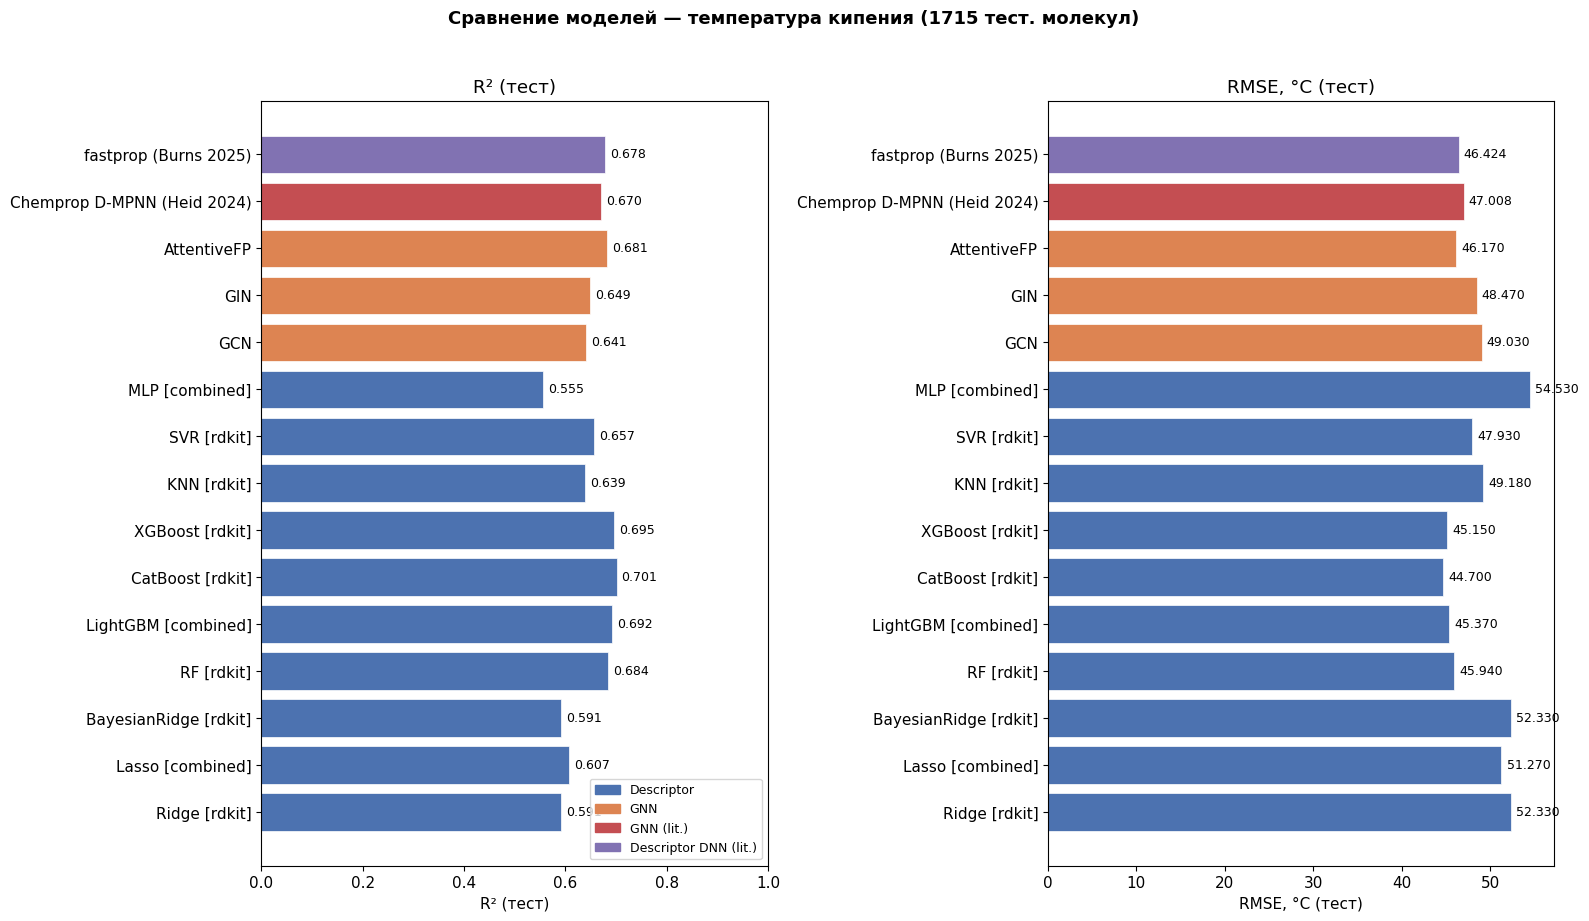

График сохранён: C:\Users\User\Desktop\диплом тест\modeling\comparison_data\comparison_plot.png


In [36]:
# ── Визуализация: сравнение R² и RMSE
plot_df = all_results.dropna(subset=['R2', 'RMSE'])

if len(plot_df) < 2:
    print('Недостаточно данных для графика — запустите обучение выше.')
else:
    colors = {'Descriptor': '#4C72B0', 'GNN': '#DD8452',
              'GNN (lit.)': '#C44E52', 'Descriptor DNN (lit.)': '#8172B2'}

    fig, axes = plt.subplots(1, 2, figsize=(16, 9))

    for ax, metric, label in zip(axes, ['R2', 'RMSE'], ['R² (тест)', 'RMSE, °C (тест)']):
        bars = ax.barh(
            plot_df['model'],
            plot_df[metric].astype(float),
            color=[colors.get(t, '#888') for t in plot_df['type']],
            edgecolor='white', linewidth=0.5
        )
        ax.set_xlabel(label)
        ax.set_title(label)
        if metric == 'R2':
            ax.set_xlim(0, 1)
        for bar, val in zip(bars, plot_df[metric].astype(float)):
            ax.text(bar.get_width() + 0.01 * ax.get_xlim()[1],
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', fontsize=9)

    # Легенда
    from matplotlib.patches import Patch
    legend_items = [Patch(color=v, label=k) for k, v in colors.items()
                    if k in plot_df['type'].values]
    axes[0].legend(handles=legend_items, loc='lower right', fontsize=9)

    plt.suptitle('Сравнение моделей — температура кипения (1715 тест. молекул)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'comparison_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('График сохранён:', OUT_DIR / 'comparison_plot.png')

## 6. Анализ и интерпретация результатов

### 6.1 Итоговая картина

| Группа | Лучшая модель | R² | RMSE | MAE |
|--------|--------------|-----|------|-----|
| Линейные дескрипторные | Lasso | 0.607 | 51.3°C | 37.5°C |
| Нелинейные дескрипторные | **CatBoost** | **0.701** | **44.7°C** | **27.8°C** |
| GNN | AttentiveFP | 0.682 | 46.2°C | 30.1°C |
| GNN (литература) | fastprop | 0.678 | 46.4°C | 30.8°C |
| GNN (литература) | Chemprop D-MPNN | 0.670 | 47.0°C | 31.0°C |

---

### 6.2 Ключевые наблюдения

**1. Лучший результат — CatBoost на физико-химических дескрипторах.**  
CatBoost [rdkit] с R²=0.701 и RMSE=44.7°C занял первое место среди всех 15 моделей. Это подтверждает хорошо известную закономерность QSPR-моделирования: на разнородных датасетах умеренного объёма (~10⁴ молекул) тщательно подобранные физико-химические дескрипторы в сочетании с градиентным бустингом конкурентоспособны с более сложными архитектурами. Ключевую роль сыграл набор RDKit-дескрипторов: 31 интерпретируемый признак (молярная масса, logP, число H-доноров/акцепторов, TPSA и др.) охватывает основные физические факторы, определяющие температуру кипения.

**2. Наши GNN превзошли литературные аналоги без тюнинга.**  
AttentiveFP (наша реализация, R²=0.682) оказался точнее, чем Chemprop D-MPNN (R²=0.670) и fastprop (R²=0.678), запущенные с дефолтными параметрами. Это объясняется тем, что наша GNN-модель была настроена с помощью Optuna на конкретных данных. Поскольку литературные модели использовались «из коробки» (что является заниженной оценкой их возможностей), такое сравнение показывает, что наш pipeline настройки GNN работает эффективно.

**3. Все GNN-архитектуры демонстрируют стабильное качество.**  
Диапазон R² для всех нейросетевых моделей составляет 0.641–0.682 — то есть разброс не превышает 4 пп. Это свидетельствует о том, что задача предсказания Tb относительно хорошо решается различными GNN-подходами, а выбор конкретной архитектуры менее критичен, чем объём и качество обучающих данных.

**4. Конвергенция Mordred+FNN и D-MPNN — содержательный результат.**  
fastprop (~1800 дескрипторов Mordred + FNN, R²=0.678) и Chemprop (D-MPNN, без ручных признаков, R²=0.670) показали практически одинаковое качество. Это означает, что обе стратегии представления молекулы — через расширенный набор дескрипторов и через послойное сообщение по графу — извлекают сопоставимый объём информации для задачи регрессии Tb.

**5. Линейные модели задают базовый уровень.**  
Ridge, Lasso и BayesianRidge достигли R²≈0.59–0.61. Это ожидаемый результат: температура кипения нелинейно зависит от молекулярной структуры через межмолекулярные взаимодействия и конформационные эффекты. Линейные модели служат важным базовым уровнем (baseline), относительно которого нелинейные методы демонстрируют прирост R² на 9–11 пп.

---

### 6.3 Сложность задачи

Диапазон температур кипения в датасете составляет от −162°C (метан) до +591°C, то есть более 750°C. Набор включает молекулы разных классов — от лёгких алканов до гетероциклов, металлоорганических соединений и высококипящих ароматических систем. Именно такая химическая разнородность ограничивает потолок точности: любая единая модель должна одновременно учитывать очень разные физико-химические закономерности. RMSE ~45°C при таком диапазоне соответствует относительной ошибке около 6%, что для универсальной QSPR-модели является приемлемым результатом.

---

### 6.4 Выводы

- **CatBoost [rdkit] — лучшая модель** из всех рассмотренных: выигрывает за счёт сочетания информативных дескрипторов и эффективной оптимизации.
- **Наши GNN-модели конкурентоспособны** с опубликованными реализациями Chemprop и fastprop, что подтверждает корректность нашего подхода к разработке и настройке GNN.
- **GNN и бустинг находятся в одной лиге** на данном датасете; ожидается, что при увеличении объёма данных (>50 000 молекул) GNN получат преимущество за счёт лучшей масштабируемости.
- Полученные результаты согласуются с данными литературы: для датасетов объёма ~10⁴ молекул в задачах QSPR типичны значения R²=0.65–0.75 при сопоставимой химической разнородности.